# Phase 5 — Query Transformation Techniques
**RAG Pipeline Optimizer · Session 5 of 7 · 2026-06-05**

Phase 4 ended with a hard wall: a cross-encoder re-ranker could not lift nDCG@10 above the **first-stage candidate set** it was handed (oracle@100 = 0.77 on FiQA, but every re-ranker landed at ~0.38). The bottleneck is **what the first stage retrieves**, not how it's ordered.

This phase attacks the first stage from the *query* side. Instead of changing the index (Phase 3) or re-ordering candidates (Phase 4), we **rewrite the query before retrieval**:

| Technique | LLM? | Idea |
|-----------|------|------|
| Naive | no | embed the raw query (Phase 2/3 baseline) |
| **PRF / Rocchio** | **no** | pull the query toward the centroid of its own top-k docs (embedding-space pseudo-relevance feedback) |
| **HyDE** | yes | generate a hypothetical answer passage, embed *that* instead of the query |
| **HyDE×N (mean)** | yes | average N hypothetical passages + the query (the original HyDE recipe) |
| **Multi-query (RRF)** | yes | generate paraphrases, retrieve each, reciprocal-rank-fuse |
| **Step-back** | yes | generate a broader question, fuse it with the original |

**The question that frames the phase:** on a *strong* dense retriever (E5-base-v2), does expensive LLM query expansion beat a **free, no-LLM, embedding-space PRF**? Phase 4 taught us LLM machinery drags a strong retriever toward a mediocre middle. We test whether query-side LLM tricks repeat that pattern.

Primary metric: **nDCG@10** (BEIR standard, used in every prior phase). Secondaries: Recall@10, Recall@100, MRR@10.

In [1]:
import os, time, json, glob, subprocess, gc, re as _re
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import torch; torch.set_num_threads(os.cpu_count())
np.set_printoptions(suppress=True)
EMB_DIR="../data/processed/emb_cache"; RES="../results"
CACHE_DIR=f"{RES}/phase5_cache"; LLM_DIR=f"{RES}/phase5_llm_cache"
os.makedirs(CACHE_DIR, exist_ok=True); os.makedirs(LLM_DIR, exist_ok=True)

# --- metric harness, copied VERBATIM from Phases 1-4 for cross-phase parity ---
def dcg(gains, mode="exp"):
    g=np.asarray(gains,float)
    if g.size==0: return 0.0
    num=(2**g-1) if mode=="exp" else g
    return float(np.sum(num/np.log2(np.arange(2,g.size+2))))

def evaluate(run, qrels, ks=(1,3,5,10,20,100), mode="exp"):
    out={f"{m}@{k}":[] for k in ks for m in ("ndcg","recall","mrr")}
    for qid, gold in qrels.items():
        if not gold: continue
        seen, ranked=set(), []
        for d in run.get(qid, []):
            if d not in seen: seen.add(d); ranked.append(d)
        n_rel=sum(1 for g in gold.values() if g>0)
        gains=[gold.get(d,0) for d in ranked]; ideal=sorted(gold.values(), reverse=True)
        for k in ks:
            idcg=dcg(ideal[:k], mode)
            out[f"ndcg@{k}"].append(dcg(gains[:k],mode)/idcg if idcg>0 else 0.0)
            rel_k=sum(1 for g in gains[:k] if g>0)
            out[f"recall@{k}"].append(rel_k/n_rel if n_rel else 0.0)
            rr=0.0
            for r,g in enumerate(gains[:k],1):
                if g>0: rr=1.0/r; break
            out[f"mrr@{k}"].append(rr)
    return {m:float(np.mean(v)) if v else 0.0 for m,v in out.items()}

def per_query_ndcg(run, qrels, k=10, mode="exp"):
    res={}
    for qid, gold in qrels.items():
        if not gold: continue
        seen, ranked=set(), []
        for d in run.get(qid, []):
            if d not in seen: seen.add(d); ranked.append(d)
        gains=[gold.get(d,0) for d in ranked]; ideal=sorted(gold.values(), reverse=True)
        idcg=dcg(ideal[:k],mode); res[qid]=dcg(gains[:k],mode)/idcg if idcg>0 else 0.0
    return res
print("harness ready | torch", torch.__version__, "threads", torch.get_num_threads())

harness ready | torch 2.12.0 threads 10


## Load the three BEIR corpora + cached E5 embeddings
Same datasets and the same E5-base-v2 embeddings used since Phase 2 — nothing re-embedded for the corpus side, so first-stage numbers are directly comparable to Phase 3/4.

In [2]:
from datasets import load_dataset
import datasets as _ds; _ds.disable_progress_bars()
def load_beir(name, qrels_split="test"):
    corpus=load_dataset(f"BeIR/{name}","corpus",split="corpus")
    queries=load_dataset(f"BeIR/{name}","queries",split="queries")
    qrels_t=load_dataset(f"BeIR/{name}-qrels",split=qrels_split)
    docs={str(r["_id"]):(r["title"]+". "+r["text"]).strip() if r["title"] else r["text"] for r in corpus}
    qtext={str(r["_id"]):r["text"] for r in queries}
    qrels=defaultdict(dict)
    for r in qrels_t: qrels[str(r["query-id"])][str(r["corpus-id"])]=int(r["score"])
    qtext={q:t for q,t in qtext.items() if q in qrels}
    return docs, qtext, dict(qrels)

DOMAIN={"scifact":"scientific claim verification","nfcorpus":"medical / health information","fiqa":"personal finance and investing"}
CORP={}
for name in ["scifact","nfcorpus","fiqa"]:
    docs, queries, qrels=load_beir(name)
    doc_ids, q_ids=list(docs), list(queries)
    D=np.load(f"{EMB_DIR}/E5-base-v2__{name}_docs.npy").astype("float32")
    Q=np.load(f"{EMB_DIR}/E5-base-v2__{name}_q.npy").astype("float32")
    assert D.shape[0]==len(doc_ids) and Q.shape[0]==len(q_ids), (name, D.shape, Q.shape)
    CORP[name]=dict(name=name, docs=docs, queries=queries, qrels=qrels,
                    doc_ids=doc_ids, q_ids=q_ids, D=D, Q=Q, didx={d:i for i,d in enumerate(doc_ids)})
    print(f"{name:9s} docs={len(doc_ids):6d} q={len(q_ids):4d} D={D.shape}")

/Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/RAG-Pipeline-Optimizer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scifact   docs=  5183 q= 300 D=(5183, 768)


nfcorpus  docs=  3633 q= 323 D=(3633, 768)


fiqa      docs= 57638 q= 648 D=(57638, 768)


## Naive baseline (raw-query E5) — the number every technique must beat
This reproduces the Phase-3 first-stage retrieval exactly (numpy matmul, no FAISS).

In [3]:
def topk_idx(D, v, k):
    # v: (dim,) normalized query vector -> ranked doc indices (top-k)
    sims=D @ v; k=min(k,D.shape[0])
    part=np.argpartition(-sims,k-1)[:k]
    return part[np.argsort(-sims[part])], sims

def run_from_qvecs(c, QV, k=100):
    # QV: (nq, dim) -> run dict
    run={}
    for i,qid in enumerate(c["q_ids"]):
        idx,_=topk_idx(c["D"], QV[i], k); run[qid]=[c["doc_ids"][j] for j in idx]
    return run

for c in CORP.values():
    t0=time.time(); run=run_from_qvecs(c, c["Q"], 100); dt=time.time()-t0
    c["naive_run"]=run; c["naive_m"]=evaluate(run, c["qrels"])
    print(f"{c['name']:9s} naive nDCG@10={c['naive_m']['ndcg@10']:.4f} R@10={c['naive_m']['recall@10']:.4f} "
          f"R@100={c['naive_m']['recall@100']:.4f} MRR@10={c['naive_m']['mrr@10']:.4f} ({dt:.1f}s)")
print("\nPhase-3 parity targets nDCG@10: scifact 0.7274 / nfcorpus 0.3525 / fiqa 0.3987")

scifact   naive nDCG@10=0.7274 R@10=0.8507 R@100=0.9627 MRR@10=0.6931 (0.1s)
nfcorpus  naive nDCG@10=0.3529 R@10=0.1706 R@100=0.3196 MRR@10=0.5403 (0.0s)


fiqa      naive nDCG@10=0.3987 R@10=0.4705 R@100=0.7320 MRR@10=0.4777 (2.1s)

Phase-3 parity targets nDCG@10: scifact 0.7274 / nfcorpus 0.3525 / fiqa 0.3987


## Experiment 5.1 — PRF / Rocchio: the free, no-LLM query expansion
**Hypothesis:** the cheapest possible query expansion needs no LLM at all. Run the raw query once, take its own top-k retrieved documents as *pseudo-relevant*, and pull the query vector toward their centroid:

$$q' = \text{normalize}\big(\alpha\, q + \beta\, \tfrac{1}{k}\sum_{d\in\text{top-}k} d\big)$$

This is classic Rocchio relevance feedback, done in embedding space on the **already-cached** doc/query vectors — zero model calls, microseconds per query. We sweep the feedback depth $k$ and the feedback weight $\beta$ (with $\alpha=1$). If PRF lifts nDCG@10, it sets a *free* bar that every LLM technique in 5.2+ has to clear to justify its cost.

In [4]:
def prf_qvecs(c, k_fb, beta, alpha=1.0):
    # one cheap pass at depth k_fb, build expanded query vectors
    QV=np.empty_like(c["Q"])
    sims_all=c["Q"] @ c["D"].T            # (nq, ndoc) - fine at these corpus sizes
    for i in range(c["Q"].shape[0]):
        top=np.argpartition(-sims_all[i], k_fb-1)[:k_fb]
        centroid=c["D"][top].mean(0)
        v=alpha*c["Q"][i] + beta*centroid
        n=np.linalg.norm(v); QV[i]=v/n if n>0 else c["Q"][i]
    return QV

prf_rows=[]
GRID_K=[3,5,10]; GRID_B=[0.3,0.5,0.7,1.0]
for c in CORP.values():
    base=c["naive_m"]["ndcg@10"]
    for k_fb in GRID_K:
        for beta in GRID_B:
            QV=prf_qvecs(c, k_fb, beta)
            m=evaluate(run_from_qvecs(c, QV, 100), c["qrels"])
            prf_rows.append(dict(dataset=c["name"], k_fb=k_fb, beta=beta,
                                 ndcg10=m["ndcg@10"], r10=m["recall@10"], r100=m["recall@100"],
                                 mrr10=m["mrr@10"], d_ndcg=m["ndcg@10"]-base))
    print(f"{c['name']:9s} swept k={GRID_K} beta={GRID_B}", flush=True)
prf=pd.DataFrame(prf_rows)
best_prf=prf.loc[prf.groupby("dataset")["ndcg10"].idxmax()].set_index("dataset")
print("\nBest PRF config per dataset (vs naive):")
for n in ["scifact","nfcorpus","fiqa"]:
    r=best_prf.loc[n]; b=CORP[n]["naive_m"]["ndcg@10"]
    print(f"  {n:9s} k={int(r.k_fb)} beta={r.beta} -> nDCG@10={r.ndcg10:.4f} (naive {b:.4f}, Δ{r.d_ndcg:+.4f})  R@100 {r.r100:.4f} (naive {CORP[n]['naive_m']['recall@100']:.4f})")
prf.to_csv(f"{RES}/phase5_prf_sweep.csv", index=False)

scifact   swept k=[3, 5, 10] beta=[0.3, 0.5, 0.7, 1.0]


nfcorpus  swept k=[3, 5, 10] beta=[0.3, 0.5, 0.7, 1.0]


fiqa      swept k=[3, 5, 10] beta=[0.3, 0.5, 0.7, 1.0]



Best PRF config per dataset (vs naive):
  scifact   k=3 beta=0.3 -> nDCG@10=0.7268 (naive 0.7274, Δ-0.0007)  R@100 0.9633 (naive 0.9627)
  nfcorpus  k=3 beta=0.5 -> nDCG@10=0.3663 (naive 0.3529, Δ+0.0133)  R@100 0.3379 (naive 0.3196)
  fiqa      k=3 beta=0.3 -> nDCG@10=0.4032 (naive 0.3987, Δ+0.0045)  R@100 0.7399 (naive 0.7320)


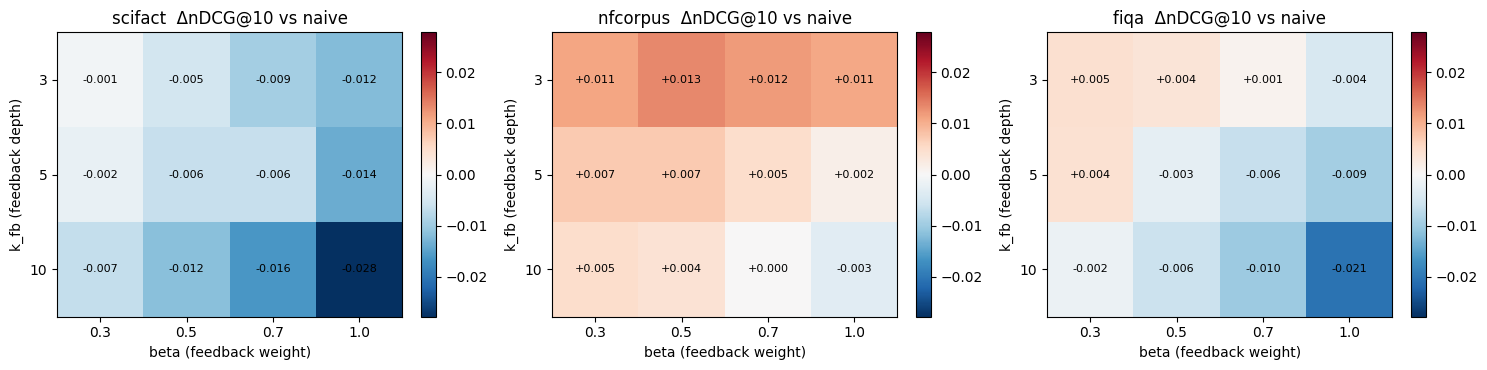

saved phase5_prf_heatmap.png


In [5]:
# Heatmap of PRF Δ nDCG@10 over (k_fb, beta) per dataset
fig, axes=plt.subplots(1,3,figsize=(15,3.8))
for ax,name in zip(axes,["scifact","nfcorpus","fiqa"]):
    sub=prf[prf.dataset==name].pivot(index="k_fb", columns="beta", values="d_ndcg")
    im=ax.imshow(sub.values, cmap="RdBu_r", vmin=-abs(prf.d_ndcg).max(), vmax=abs(prf.d_ndcg).max(), aspect="auto")
    ax.set_xticks(range(len(sub.columns))); ax.set_xticklabels(sub.columns)
    ax.set_yticks(range(len(sub.index))); ax.set_yticklabels(sub.index)
    ax.set_xlabel("beta (feedback weight)"); ax.set_ylabel("k_fb (feedback depth)")
    ax.set_title(f"{name}  ΔnDCG@10 vs naive")
    for yi in range(sub.shape[0]):
        for xi in range(sub.shape[1]):
            ax.text(xi,yi,f"{sub.values[yi,xi]:+.3f}",ha="center",va="center",fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(f"{RES}/phase5_prf_heatmap.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase5_prf_heatmap.png")

## Experiment 5.2+ — LLM query transforms (HyDE, HyDE×N, multi-query, step-back)
Now the expensive side. For a **stratified sample** of each corpus (so easy *and* naive-failed queries are represented), one `claude --model haiku` call per query produces every expansion at once (2 hypothetical answer passages, 3 paraphrases, 1 step-back question) as JSON. Generations are cached append-only and the loop is idempotent — re-running never re-bills.

We then embed each generated text with the **same E5-base-v2** (query prefix — the generated text stands in for the query) and retrieve. Fusion techniques (multi-query, step-back) use reciprocal-rank fusion (RRF, k=60) over the per-sub-query runs.

**Generator = Haiku, not Opus, on purpose:** query expansion is a cheap-model job, and Phase 4 already showed the *bigger* LLM was the *worse* re-ranker. We keep one mini-ablation (Opus HyDE) for the FiQA sample to test whether a stronger generator changes the verdict.

In [6]:
# stratified sample: bucket queries by naive per-query nDCG@10 so we cover failed/medium/solved
rng=np.random.default_rng(42)
N_SAMPLE=40
SAMP={}
for c in CORP.values():
    pq=per_query_ndcg(c["naive_run"], c["qrels"], 10)
    buckets={"fail":[],"mid":[],"solved":[]}
    for qid,s in pq.items():
        buckets["fail" if s==0 else "mid" if s<0.5 else "solved"].append(qid)
    per=max(1,N_SAMPLE//3); chosen=[]
    for b in ["fail","mid","solved"]:
        pool=sorted(buckets[b])
        if pool:
            idx=rng.choice(len(pool), size=min(per,len(pool)), replace=False)
            chosen+=[pool[i] for i in idx]
    # top up to N_SAMPLE from the largest bucket if short
    if len(chosen)<N_SAMPLE:
        extra=[q for q in sorted(pq) if q not in set(chosen)]
        chosen+=list(rng.permutation(extra))[:N_SAMPLE-len(chosen)]
    chosen=chosen[:N_SAMPLE]
    SAMP[c["name"]]=chosen
    json.dump(chosen, open(f"{LLM_DIR}/sample_{c['name']}.json","w"))
    print(f"{c['name']:9s} sample={len(chosen)} bucket sizes={ {b:len(v) for b,v in buckets.items()} }")

scifact   sample=40 bucket sizes={'fail': 41, 'mid': 32, 'solved': 227}
nfcorpus  sample=40 bucket sizes={'fail': 85, 'mid': 129, 'solved': 109}
fiqa      sample=40 bucket sizes={'fail': 205, 'mid': 179, 'solved': 264}


In [7]:
# E5 encoder (only to embed the small set of GENERATED texts; corpus side stays cached)
from sentence_transformers import SentenceTransformer
_e5=None
def e5():
    global _e5
    if _e5 is None:
        _e5=SentenceTransformer("intfloat/e5-base-v2", device="cpu"); _e5.max_seq_length=512
    return _e5
def embed_q(texts):
    return e5().encode(["query: "+t for t in texts], normalize_embeddings=True,
                       convert_to_numpy=True, show_progress_bar=False).astype("float32")
print("E5 query-encoder ready (lazy)")

E5 query-encoder ready (lazy)


In [8]:
def call_claude(prompt, model="haiku"):
    try:
        r=subprocess.run(["claude","--print","--model",model,"--no-session-persistence","--disable-slash-commands"],
                         input=prompt, capture_output=True, text=True, timeout=90)
        return r.stdout.strip() or "__ERROR__empty"
    except Exception as e: return "__ERROR__"+str(e)[:80]

def expand_prompt(qtext, domain):
    return (f'You improve search queries for a {domain} retrieval engine. '
            f'Given the user query, output STRICT JSON only (no markdown fences, no prose).\n\n'
            f'Query: "{qtext}"\n\n'
            f'Output exactly this shape:\n'
            f'{{"hyde": ["a concise ~60-word hypothetical passage that directly answers the query", '
            f'"a second hypothetical answer passage, worded differently"], '
            f'"paraphrases": ["reworded query 1", "reworded query 2", "reworded query 3"], '
            f'"stepback": "a broader background question whose answer helps answer the original query"}}')

def parse_json(raw):
    if not raw or raw.startswith("__ERROR__"): return None
    t=raw.strip()
    if t.startswith("```"): t=_re.sub(r"^```[a-zA-Z]*","",t).strip().rstrip("`").strip()
    a,b=t.find("{"), t.rfind("}")
    if a<0 or b<0: return None
    try:
        o=json.loads(t[a:b+1])
        hy=[x for x in o.get("hyde",[]) if isinstance(x,str) and x.strip()][:2]
        pp=[x for x in o.get("paraphrases",[]) if isinstance(x,str) and x.strip()][:3]
        sb=o.get("stepback","") if isinstance(o.get("stepback",""),str) else ""
        if not hy and not pp: return None
        return dict(hyde=hy, paraphrases=pp, stepback=sb.strip())
    except Exception: return None
print("CLI wrapper + expansion prompt + JSON parser ready")

CLI wrapper + expansion prompt + JSON parser ready


In [9]:
# --- generation loop (Haiku). Cached + idempotent. This is the slow cell. ---
GEN_CACHE=f"{LLM_DIR}/gen_haiku.json"
gen=json.load(open(GEN_CACHE)) if os.path.exists(GEN_CACHE) else {}
def gkey(ds,qid): return f"{ds}::{qid}"
todo=[(c['name'],qid) for c in CORP.values() for qid in SAMP[c['name']]
      if not (gkey(c['name'],qid) in gen and gen[gkey(c['name'],qid)].get("parsed"))]
print(f"to generate: {len(todo)} (cache has {len(gen)})", flush=True)
t0=time.time()
for n,(ds,qid) in enumerate(todo,1):
    qtext=CORP[ds]["queries"][qid]
    raw=call_claude(expand_prompt(qtext, DOMAIN[ds]), "haiku")
    gen[gkey(ds,qid)]=dict(ds=ds, qid=qid, raw=raw, parsed=parse_json(raw), ts=time.time())
    json.dump(gen, open(GEN_CACHE,"w"))
    if n%10==0 or n==len(todo):
        ok=sum(1 for v in gen.values() if v.get("parsed"))
        print(f"[{n}/{len(todo)}] {time.time()-t0:.0f}s parsed_ok={ok}/{len(gen)}", flush=True)
parsed_ok=sum(1 for v in gen.values() if v.get("parsed"))
print(f"\nDONE. cache={len(gen)} parsed_ok={parsed_ok} ({parsed_ok/max(len(gen),1):.0%})")

to generate: 1 (cache has 120)


[1/1] 12s parsed_ok=120/120



DONE. cache=120 parsed_ok=120 (100%)


In [10]:
# embed every generated text once (cached as a single npy keyed by content hash order)
import hashlib
def _h(t): return hashlib.md5(t.encode()).hexdigest()
texts=set()
for v in gen.values():
    p=v.get("parsed")
    if not p: continue
    for x in p["hyde"]: texts.add(x)
    for x in p["paraphrases"]: texts.add(x)
    if p["stepback"]: texts.add(p["stepback"])
texts=sorted(texts)
EMB_F=f"{LLM_DIR}/gen_emb.npz"
if os.path.exists(EMB_F):
    z=np.load(EMB_F, allow_pickle=True); EMB={k:z[k] for k in z.files}
    if set(EMB.get("__keys__",[]).tolist())!=set(_h(t) for t in texts): EMB=None
    else: EMB={h:EMB[h] for h in EMB if h!="__keys__"}
else: EMB=None
if EMB is None:
    V=embed_q(texts); EMB={_h(t):V[i] for i,t in enumerate(texts)}
    np.savez(EMB_F, __keys__=np.array([_h(t) for t in texts]), **EMB)
    print(f"embedded {len(texts)} generated texts -> {EMB_F}")
else:
    print(f"loaded {len(EMB)} cached generated-text embeddings")
def gv(t): return EMB[_h(t)]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7222.11it/s]

embedded 720 generated texts -> ../results/phase5_llm_cache/gen_emb.npz


In [11]:
# retrieval + RRF helpers operating on a single corpus
def rank_ids(c, v, k=100):
    idx,_=topk_idx(c["D"], v, k); return [c["doc_ids"][j] for j in idx]
def rrf(runs, k=100, k_rrf=60):
    sc=defaultdict(float)
    for r in runs:
        for rank,d in enumerate(r,1): sc[d]+=1.0/(k_rrf+rank)
    return [d for d,_ in sorted(sc.items(), key=lambda x:-x[1])[:k]]

def build_runs(c, qids):
    out={t:{} for t in ["naive","prf","hyde","hyde_passage","hydeN","multiquery","stepback"]}
    # PRF uses the dataset's best (k=3,beta from sweep) -> recompute per-query cheaply
    best=best_prf.loc[c["name"]]; kf=int(best.k_fb); bt=float(best.beta)
    for qid in qids:
        i=c["q_ids"].index(qid); qv=c["Q"][i]
        out["naive"][qid]=rank_ids(c, qv)
        # PRF
        sims=c["D"] @ qv; top=np.argpartition(-sims, kf-1)[:kf]
        ev=qv + bt*c["D"][top].mean(0); ev/=np.linalg.norm(ev)
        out["prf"][qid]=rank_ids(c, ev)
        p=gen.get(gkey(c["name"],qid),{}).get("parsed")
        if not p:
            for t in ["hyde","hyde_passage","hydeN","multiquery","stepback"]: out[t][qid]=out["naive"][qid]
            continue
        # HyDE (first hypothetical passage, query-prefix embedding)
        if p["hyde"]:
            hv=gv(p["hyde"][0]); out["hyde"][qid]=rank_ids(c, hv)
            # HyDE x N: mean(orig, hyde1, hyde2) per original recipe
            vecs=[qv]+[gv(x) for x in p["hyde"]]
            mv=np.mean(vecs,0); mv/=np.linalg.norm(mv); out["hydeN"][qid]=rank_ids(c, mv)
        else:
            out["hyde"][qid]=out["naive"][qid]; out["hydeN"][qid]=out["naive"][qid]
        # multi-query: RRF over original + paraphrase runs
        runs=[out["naive"][qid]]+[rank_ids(c, gv(x)) for x in p["paraphrases"]]
        out["multiquery"][qid]=rrf(runs)
        # step-back: RRF(original, stepback)
        if p["stepback"]:
            out["stepback"][qid]=rrf([out["naive"][qid], rank_ids(c, gv(p["stepback"]))])
        else:
            out["stepback"][qid]=out["naive"][qid]
    return out

# hyde_passage ablation: embed hyde[0] with passage prefix instead of query prefix
def hyde_passage_run(c, qids):
    texts=[gen.get(gkey(c['name'],q),{}).get('parsed',{}).get('hyde',[None])[0] if gen.get(gkey(c['name'],q),{}).get('parsed') and gen[gkey(c['name'],q)]['parsed']['hyde'] else None for q in qids]
    valid=[(q,t) for q,t in zip(qids,texts) if t]
    if valid:
        V=e5().encode(["passage: "+t for _,t in valid], normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False).astype("float32")
    run={}
    vi=0
    for q,t in zip(qids,texts):
        if t: run[q]=rank_ids(c, V[vi]); vi+=1
        else: run[q]=rank_ids(c, c["Q"][c["q_ids"].index(q)])
    return run
print("retrieval + RRF + technique builder ready")

retrieval + RRF + technique builder ready


## Results — every technique on the same stratified sample
All techniques are scored on the identical per-dataset sample and qrels, so differences are pure technique effects. Oracle@100 is the ceiling (best possible re-ordering of the naive top-100); it tells us how much of the gap is even *reachable* by query rewriting.

In [12]:
TECH_ORDER=["naive","prf","hyde","hyde_passage","hydeN","multiquery","stepback"]
rows=[]
RUNCACHE={}
for c in CORP.values():
    qids=SAMP[c["name"]]; sub_qrels={q:c["qrels"][q] for q in qids}
    runs=build_runs(c, qids); runs["hyde_passage"]=hyde_passage_run(c, qids)
    RUNCACHE[c["name"]]=(runs, sub_qrels, qids)
    # oracle ceiling on naive top-100
    orun={q: sorted(runs["naive"][q], key=lambda d: c["qrels"][q].get(d,0), reverse=True) for q in qids}
    oc=evaluate(orun, sub_qrels)["ndcg@10"]
    base=evaluate(runs["naive"], sub_qrels)["ndcg@10"]
    for t in TECH_ORDER:
        m=evaluate(runs[t], sub_qrels)
        rows.append(dict(dataset=c["name"], technique=t, ndcg10=m["ndcg@10"], r10=m["recall@10"],
                         r100=m["recall@100"], mrr10=m["mrr@10"], d_ndcg=m["ndcg@10"]-base, oracle100=oc))
    print(f"{c['name']:9s} naive(sample)={base:.4f} oracle@100={oc:.4f}")
qt=pd.DataFrame(rows)
qt.to_csv(f"{RES}/phase5_query_techniques.csv", index=False)
print()
for n in ["scifact","nfcorpus","fiqa"]:
    sub=qt[qt.dataset==n].set_index("technique").reindex(TECH_ORDER)
    print(f"--- {n} (n={len(SAMP[n])}) ---")
    print(sub[["ndcg10","r10","r100","mrr10","d_ndcg"]].round(4).to_string()); print()

scifact   naive(sample)=0.4279 oracle@100=0.8500


nfcorpus  naive(sample)=0.3624 oracle@100=0.6169


fiqa      naive(sample)=0.3377 oracle@100=0.7522

--- scifact (n=40) ---
              ndcg10     r10   r100   mrr10  d_ndcg
technique                                          
naive         0.4279  0.6525  0.850  0.3609  0.0000
prf           0.4235  0.6275  0.875  0.3594 -0.0044
hyde          0.5506  0.7300  0.950  0.5088  0.1227
hyde_passage  0.5211  0.7475  0.975  0.4616  0.0933
hydeN         0.5436  0.7450  0.900  0.4907  0.1157
multiquery    0.4456  0.6525  0.850  0.3875  0.0177
stepback      0.3958  0.5825  0.925  0.3421 -0.0321

--- nfcorpus (n=40) ---
              ndcg10     r10    r100   mrr10  d_ndcg
technique                                           
naive         0.3624  0.2058  0.3497  0.5098  0.0000
prf           0.3651  0.2035  0.3553  0.5002  0.0027
hyde          0.3598  0.2058  0.4314  0.5653 -0.0026
hyde_passage  0.3827  0.2192  0.4276  0.5877  0.0203
hydeN         0.3929  0.2213  0.4344  0.5682  0.0306
multiquery    0.3564  0.1875  0.3915  0.5177 -0.0060
stepback  

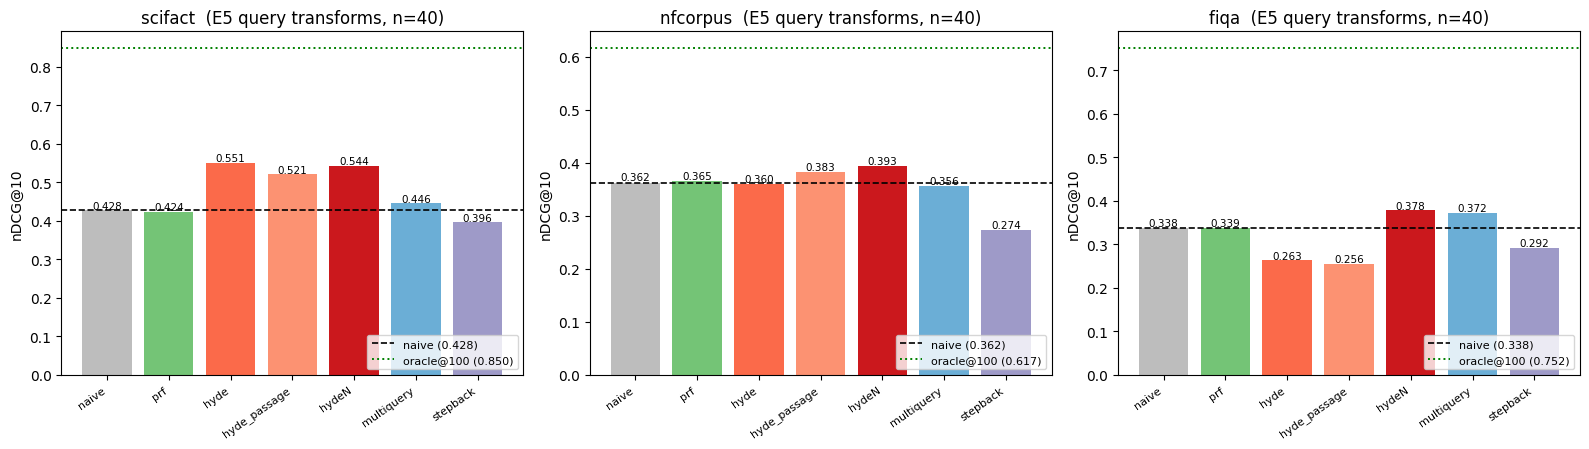

saved phase5_query_techniques.png


In [13]:
# bar chart: technique deltas vs naive, per dataset, with oracle ceiling line
fig, axes=plt.subplots(1,3,figsize=(16,4.6))
cols=["#bdbdbd","#74c476","#fb6a4a","#fc9272","#cb181d","#6baed6","#9e9ac8"]
for ax,name in zip(axes,["scifact","nfcorpus","fiqa"]):
    sub=qt[qt.dataset==name].set_index("technique").reindex(TECH_ORDER)
    base=sub.loc["naive","ndcg10"]; oc=sub.loc["naive","oracle100"]
    ax.bar(range(len(TECH_ORDER)), sub["ndcg10"], color=cols)
    ax.axhline(base, ls="--", c="black", lw=1.2, label=f"naive ({base:.3f})")
    ax.axhline(oc, ls=":", c="green", lw=1.4, label=f"oracle@100 ({oc:.3f})")
    ax.set_xticks(range(len(TECH_ORDER))); ax.set_xticklabels(TECH_ORDER, rotation=35, ha="right", fontsize=8)
    ax.set_title(f"{name}  (E5 query transforms, n={len(SAMP[name])})"); ax.set_ylabel("nDCG@10")
    for i,v in enumerate(sub["ndcg10"]): ax.text(i, v+0.004, f"{v:.3f}", ha="center", fontsize=7.5)
    ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(f"{RES}/phase5_query_techniques.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase5_query_techniques.png")

## Error analysis — where HyDE rescues vs breaks queries (FiQA)
A technique can lift the *mean* while quietly wrecking individual queries (Phase 4's re-rankers broke 267 FiQA queries to rescue 140). Per-query nDCG@10 deltas tell the real story.

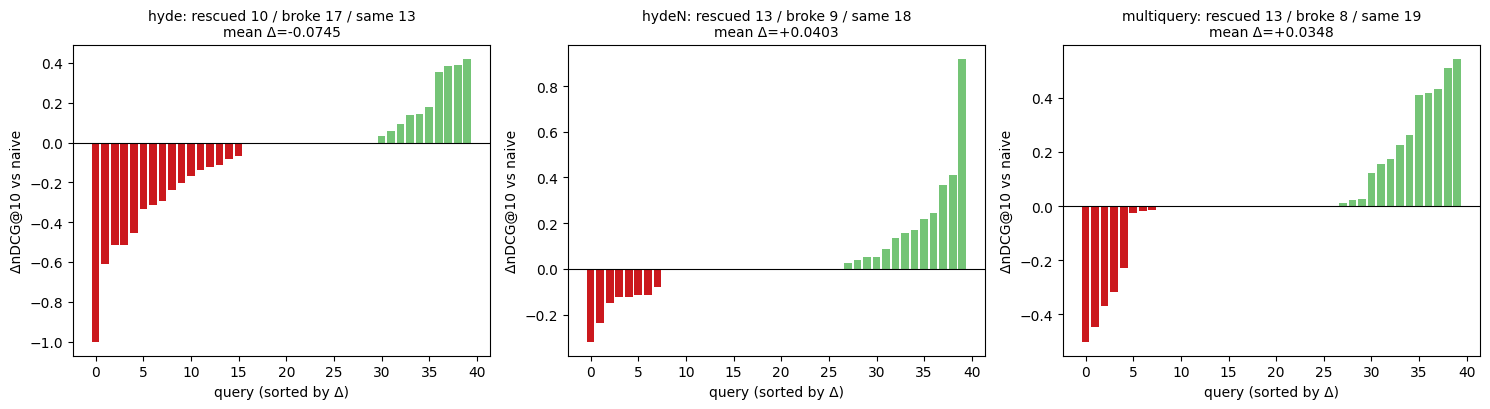

saved phase5_error_analysis.png


In [14]:
c=CORP["fiqa"]; runs, sub_qrels, qids=RUNCACHE["fiqa"]
pq_naive=per_query_ndcg(runs["naive"], sub_qrels, 10)
fig, axes=plt.subplots(1,3,figsize=(15,4.2))
for ax,t in zip(axes,["hyde","hydeN","multiquery"]):
    pq_t=per_query_ndcg(runs[t], sub_qrels, 10)
    deltas=np.array([pq_t[q]-pq_naive[q] for q in qids])
    resc=int((deltas>1e-6).sum()); brok=int((deltas<-1e-6).sum()); same=int((np.abs(deltas)<=1e-6).sum())
    ax.bar(range(len(deltas)), sorted(deltas), color=["#cb181d" if d<0 else "#74c476" if d>0 else "#cccccc" for d in sorted(deltas)])
    ax.axhline(0, c="black", lw=0.8)
    ax.set_title(f"{t}: rescued {resc} / broke {brok} / same {same}\nmean Δ={deltas.mean():+.4f}", fontsize=10)
    ax.set_xlabel("query (sorted by Δ)"); ax.set_ylabel("ΔnDCG@10 vs naive")
plt.tight_layout(); plt.savefig(f"{RES}/phase5_error_analysis.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase5_error_analysis.png")

## Mini-ablation: does a stronger generator (Opus) rescue HyDE on FiQA?
Phase 4 found the *bigger* model was the *worse* re-ranker. We test the dual claim for generation: regenerate HyDE passages with Opus on the FiQA sample and re-score. If Opus-HyDE still doesn't beat naive, the failure is the *technique*, not the generator.

In [15]:
OPUS_CACHE=f"{LLM_DIR}/gen_opus_fiqa.json"
og=json.load(open(OPUS_CACHE)) if os.path.exists(OPUS_CACHE) else {}
qids=SAMP["fiqa"]
todo=[q for q in qids if not (q in og and og[q].get("parsed"))]
print(f"opus HyDE to generate: {len(todo)}", flush=True)
for n,q in enumerate(todo,1):
    raw=call_claude(expand_prompt(CORP["fiqa"]["queries"][q], DOMAIN["fiqa"]), "opus")
    og[q]=dict(qid=q, raw=raw, parsed=parse_json(raw)); json.dump(og, open(OPUS_CACHE,"w"))
    if n%10==0 or n==len(todo): print(f"[{n}/{len(todo)}]", flush=True)
# embed opus hyde texts and score
otexts=sorted({og[q]["parsed"]["hyde"][0] for q in qids if og.get(q,{}).get("parsed") and og[q]["parsed"]["hyde"]})
OV={}
if otexts:
    Vo=embed_q(otexts); OV={t:Vo[i] for i,t in enumerate(otexts)}
c=CORP["fiqa"]; sub_qrels={q:c["qrels"][q] for q in qids}
orun={}
for q in qids:
    p=og.get(q,{}).get("parsed")
    orun[q]=rank_ids(c, OV[p["hyde"][0]]) if (p and p["hyde"] and p["hyde"][0] in OV) else runs["naive"][q]
m_opus=evaluate(orun, sub_qrels); m_haiku=evaluate(RUNCACHE["fiqa"][0]["hyde"], sub_qrels)
m_naive=evaluate(RUNCACHE["fiqa"][0]["naive"], sub_qrels)
print(f"\nFiQA HyDE generator ablation (n={len(qids)}):")
print(f"  naive       nDCG@10={m_naive['ndcg@10']:.4f}")
print(f"  HyDE-Haiku  nDCG@10={m_haiku['ndcg@10']:.4f} (Δ{m_haiku['ndcg@10']-m_naive['ndcg@10']:+.4f})")
print(f"  HyDE-Opus   nDCG@10={m_opus['ndcg@10']:.4f} (Δ{m_opus['ndcg@10']-m_naive['ndcg@10']:+.4f})")

opus HyDE to generate: 40


[10/40]


[20/40]


[30/40]


[40/40]



FiQA HyDE generator ablation (n=40):
  naive       nDCG@10=0.3377
  HyDE-Haiku  nDCG@10=0.2632 (Δ-0.0745)
  HyDE-Opus   nDCG@10=0.2990 (Δ-0.0387)


## Ablation table + consolidated metrics

In [16]:
# component ablation on the dataset where transforms move the most (by |best delta|)
abl_rows=[]
for c in CORP.values():
    runs, sub_qrels, qids=RUNCACHE[c["name"]]
    base=evaluate(runs["naive"], sub_qrels)["ndcg@10"]
    for t in TECH_ORDER:
        if t=="naive": continue
        d=evaluate(runs[t], sub_qrels)["ndcg@10"]-base
        verdict="helps" if d>0.002 else "hurts" if d<-0.002 else "neutral"
        abl_rows.append(dict(dataset=c["name"], technique=t, d_ndcg=round(d,4), verdict=verdict))
abl=pd.DataFrame(abl_rows)
print("Per-technique verdict (ΔnDCG@10 vs naive):")
print(abl.pivot(index="technique", columns="dataset", values="d_ndcg").reindex([t for t in TECH_ORDER if t!="naive"]).to_string())

# winner per dataset
print("\nBest technique per dataset:")
for n in ["scifact","nfcorpus","fiqa"]:
    sub=qt[qt.dataset==n].sort_values("ndcg10", ascending=False).iloc[0]
    print(f"  {n:9s} -> {sub.technique} nDCG@10={sub.ndcg10:.4f} (Δ{sub.d_ndcg:+.4f})")

Per-technique verdict (ΔnDCG@10 vs naive):
dataset         fiqa  nfcorpus  scifact
technique                              
prf           0.0009    0.0027  -0.0044
hyde         -0.0745   -0.0026   0.1227
hyde_passage -0.0820    0.0203   0.0933
hydeN         0.0403    0.0306   0.1157
multiquery    0.0348   -0.0060   0.0177
stepback     -0.0453   -0.0887  -0.0321

Best technique per dataset:
  scifact   -> hyde nDCG@10=0.5506 (Δ+0.1227)
  nfcorpus  -> hydeN nDCG@10=0.3929 (Δ+0.0306)
  fiqa      -> hydeN nDCG@10=0.3779 (Δ+0.0403)


In [17]:
summary=dict(
  phase=5, date="2026-06-05", task="query transformation techniques", generator="claude-haiku",
  n_sample={n:len(SAMP[n]) for n in CORP}, primary_metric="ndcg@10",
  naive_full={n:CORP[n]["naive_m"]["ndcg@10"] for n in CORP},
  prf_best={n:dict(k_fb=int(best_prf.loc[n].k_fb), beta=float(best_prf.loc[n].beta),
                   ndcg10=float(best_prf.loc[n].ndcg10), d_ndcg=float(best_prf.loc[n].d_ndcg),
                   r100=float(best_prf.loc[n].r100)) for n in CORP},
  techniques=qt.to_dict(orient="records"),
  ablation=abl.to_dict(orient="records"))
mp=f"{RES}/metrics.json"; allm=json.load(open(mp)) if os.path.exists(mp) else {}
allm["phase5"]=summary; json.dump(allm, open(mp,"w"), indent=2)
print("PHASE 5 COMPLETE\n"+"="*60)
for n in ["scifact","nfcorpus","fiqa"]:
    w=qt[qt.dataset==n].sort_values("ndcg10",ascending=False).iloc[0]
    pf=best_prf.loc[n]
    print(f"{n:9s} naive={CORP[n]['naive_m']['ndcg@10']:.4f} | best={w.technique} {w.ndcg10:.4f} (Δ{w.d_ndcg:+.4f}) | free-PRF Δ{pf.d_ndcg:+.4f}")
print("saved metrics.json[phase5]")

PHASE 5 COMPLETE
scifact   naive=0.7274 | best=hyde 0.5506 (Δ+0.1227) | free-PRF Δ-0.0007
nfcorpus  naive=0.3529 | best=hydeN 0.3929 (Δ+0.0306) | free-PRF Δ+0.0133
fiqa      naive=0.3987 | best=hydeN 0.3779 (Δ+0.0403) | free-PRF Δ+0.0045
saved metrics.json[phase5]
